# Visualization for Assignment 3

In [2]:
# Dataset of Interest:

# Crime Severity Index 2008 from Ontario’s Open Data Catalogue

# Link to Dataset
# https://data.ontario.ca/dataset/crime-severity/resource/4e1ab2e6-3a93-4692-9769-501e7d285b98

# Visualization Codes

import os
os.getcwd()

'/Users/bukkyshonibare/Desktop/DSI/visualization/02_activities/assignments/participation/Assignment 3'

In [ ]:
# Checking what Python sees

import os

os.listdir()

['.DS_Store',
 'Visualization for assignment 3.ipynb',
 'assignment_3.md',
 'Screenshot 2026-01-29 at 17.57.36.png',
 'CSI_2008_Full_Data.csv',
 'Crime Severity Index Viz.twbx',
 'Visualization - Crime Severity Index 2008.png']

In [ ]:
# Loading the Dataset

df = pd.read_csv(
    "CSI_2008_Full_Data.csv",
    sep="\t",
    engine="python",
    encoding_errors="ignore"
)

df.head()

,CSI_2008_Full Data
0,"Year,Geography,Crime_Severity_Index"
1,"2008,Ontario (7),70.68"
2,"2009,Ontario (7),68.93"
3,"2010,Ontario (7),65.15"
4,"2011,Ontario (7),60.7"


In [ ]:
# Reading the file as comma-separated CSV, not a tab-separated

import pandas as pd

df = pd.read_csv(
    "CSI_2008_Full_Data.csv",
    engine="python"
)

df.head()


,,CSI_2008_Full Data
Year,Geography,Crime_Severity_Index
2008,Ontario (7),70.68
2009,Ontario (7),68.93
2010,Ontario (7),65.15
2011,Ontario (7),60.7


In [12]:
# Confirming the dataset loads correctly

df.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 56 entries, ('Year', 'Geography') to ('2012', 'Nunavut (15)')
Data columns (total 1 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   CSI_2008_Full Data  56 non-null     object
dtypes: object(1)
memory usage: 1.2+ KB


In [ ]:
# Telling pandas how to read the CSV file properly

import pandas as pd

df = pd.read_csv(
    "CSI_2008_Full_Data.csv",
    header=0,
    index_col=False,
    engine="python"
)

df.head()

/var/folders/ky/88t8kgx162110fyl6mxm0llm0000gn/T/ipykernel_3241/620322864.py:3: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(


,CSI_2008_Full Data
0,Year
1,2008
2,2009
3,2010
4,2011


In [ ]:
# Spliting the single column into three columns

df = df.reset_index(drop=True)

In [ ]:
# Saving the final, clean dataset

df = df.iloc[:, 0].str.split(",", expand=True)

In [21]:
# Naming the columns properly

import pandas as pd

df = pd.read_csv(
    "CSI_2008_Full_Data.csv",
    sep=",",
    header=0,
    engine="python"
)

df.head()


,,CSI_2008_Full Data
Year,Geography,Crime_Severity_Index
2008,Ontario (7),70.68
2009,Ontario (7),68.93
2010,Ontario (7),65.15
2011,Ontario (7),60.7


In [ ]:
# Skipping the unnecessary title rows in the file

import pandas as pd

df = pd.read_csv(
    "CSI_2008_Full_Data.csv",
    sep=",",
    skiprows=1,   # skip the title row
    header=0,     # use Year, Geography, CSI as headers
    engine="python"
)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55 entries, 0 to 54
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  55 non-null     int64  
 1   Geography             55 non-null     object 
 2   Crime_Severity_Index  55 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 1.4+ KB


,Year,Geography,Crime_Severity_Index
0,2008,Ontario (7),70.68
1,2009,Ontario (7),68.93
2,2010,Ontario (7),65.15
3,2011,Ontario (7),60.70
4,2012,Ontario (7),58.40


In [25]:
df.to_csv("CSI_2008_clean_FINAL.csv", index=False)

In [26]:
df = pd.read_csv("CSI_2008_clean_FINAL.csv")

In [ ]:
# Identifying relevant geographies

province_means = (
    df.groupby("Geography")["Crime_Severity_Index"]
    .mean()
    .sort_values(ascending=False)
)
province_means


Geography
Northwest Territories (15)        336.778
Nunavut (15)                      332.404
Yukon                             169.178
Manitoba                          123.598
Thunder Bay, Ontario              104.882
British Columbia (32)             104.534
London, Ontario                    81.554
St.Catharines-Niagara, Ontario     70.176
Ontario (7)                        64.772
Barrie, Ontario (8)                58.650
Guelph, Ontario (8)                53.258
Name: Crime_Severity_Index, dtype: float64

In [28]:
# Selecting relevant geographies

selected_geographies = [
    "Northwest Territories (15)",
    "Nunavut (15)",
    "Ontario (7)",
    "British Columbia (32)"
]


In [29]:
# Subsetting the data

selected_geographies = [
    "Northwest Territories (15)",
    "Nunavut (15)",
    "Ontario (7)",
    "British Columbia (32)"
]

df_subset = df[df["Geography"].isin(selected_geographies)]


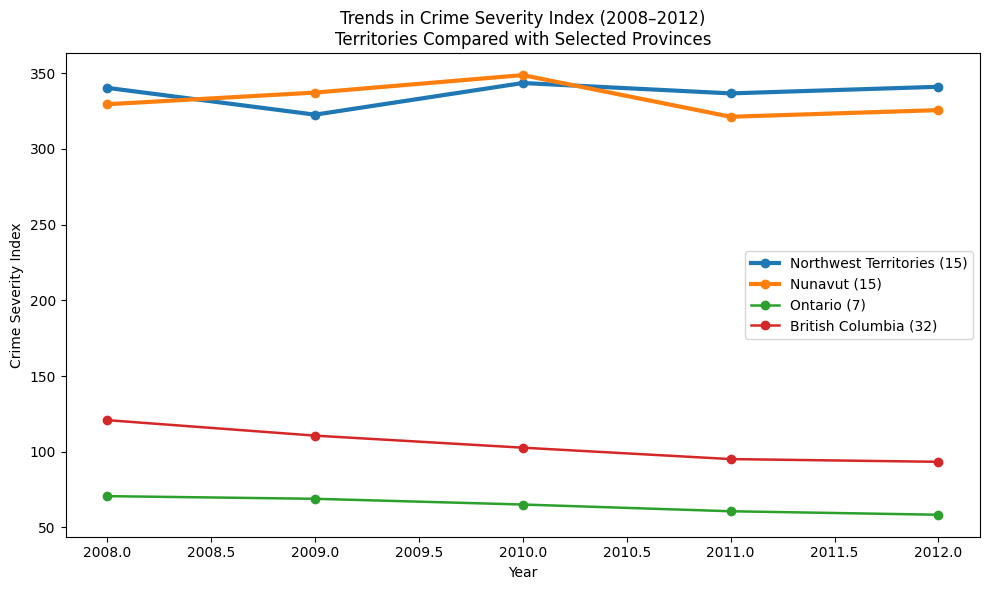

In [31]:
# Plotting the data by comparing territories with selected provinces

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for geo in selected_geographies:
    data = df_subset[df_subset["Geography"] == geo]
    linewidth = 3 if geo in ["Northwest Territories (15)", "Nunavut (15)"] else 1.8
    
    plt.plot(
        data["Year"],
        data["Crime_Severity_Index"],
        marker="o",
        linewidth=linewidth,
        label=geo
    )

plt.xlabel("Year")
plt.ylabel("Crime Severity Index")
plt.title(
    "Trends in Crime Severity Index (2008–2012)\n"
    "Territories Compared with Selected Provinces"
)
plt.legend()
plt.tight_layout()
plt.show()
